# Crecimiento de Empresas Colombianas

### Proyecto Final - Optimización e Inteligencia Artificial

---

## Integrantes

<table>
  <tr><th>Nombre</th><th>Correo</th></tr>
  <tr><td>Dylan Ramirez Blanquicet</td><td><a href="mailto:dyramirezb@unal.edu.co">dyramirezb@unal.edu.co</a></td></tr>
  <tr><td>Andres Felipe Guerra Amaris</td><td><a href="mailto:anguerraa@unal.edu.co">anguerraa@unal.edu.co</a></td></tr>
  <tr><td>Jerónimo Hoyos Botero</td><td><a href="mailto:jhoyosbo@unal.edu.co">jhoyosbo@unal.edu.co</a></td></tr>
  <tr><td>Pedro Aristizabal Alzate</td><td><a href="mailto:paristizabala@unal.edu.co">paristizabala@unal.edu.co</a></td></tr>
</table>

## Índice

1. [Objetivo](#sec-1)
2. [Diccionario de datos](#sec-2)
3. [Carga de datos](#sec-3)
4. [Exploración inicial](#sec-4)
5. [Limpieza de nombres de columnas](#sec-5)
6. [Limpieza de variables financieras](#sec-6)
7. [Formateo de CIIU y año de corte](#sec-7)
8. [Análisis de duplicados](#sec-8)
9. [Exploración de variables categóricas](#sec-9)
10. [Limpieza de `ciudad_domicilio`](#sec-10)
    1. [Detección de variantes](#sec-10-1)
    1. [Normalización y corrección](#sec-10-2)
    1. [Caso especial: Ferretería Central (Boyacá)](#sec-10-3)
11. [Limpieza de `departamento_domicilio`](#sec-11)
    1. [Detección de variantes](#sec-11-1)
    1. [Normalización y corrección](#sec-11-2)
    1. [Corrección de errores cruzados ciudad-departamento y homologación DIVIPOLA](#sec-11-3)
    1. [Verificación de cruces anómalos](#sec-11-4)
    1. [Homónimos legítimos](#sec-11-5)
    1. [Verificación final](#sec-11-6)
12. [Consolidación de razón social por NIT](#sec-12)
    1. [Detección de inconsistencias](#sec-12-1)
    1. [Corrección: se conserva el nombre más reciente](#sec-12-2)
    1. [Verificación](#sec-12-3)
13. [Revisión de activos totales en cero](#sec-13)

<a id="sec-1"></a>
## 1. Objetivo

La **Superintendencia de Sociedades** cuenta con tableros descriptivos que muestran *qué pasó* con las empresas del país, pero no con un mecanismo que anticipe *qué pasará*. Este reto fue propuesto en el marco del concurso *Datos al Ecosistema 2025* del MinTIC.

**Objetivo:** construir un modelo de **regresión supervisada** que, a partir de la información histórica de las 10.000 empresas más grandes de Colombia, estime la **ganancia (pérdida)** proyectada de las empresas por sector económico, ubicación y tamaño.

**Fuente de datos:** [10.000 Empresas más Grandes del País – datos.gov.co](https://www.datos.gov.co/Comercio-Industria-y-Turismo/10-000-Empresas-mas-Grandes-del-Pa-s/6cat-2gcs/about_data). 

<a id="sec-2"></a>
## 2. Diccionario de datos

| Variable | Tipo | Descripción |
|---|---|---|
| `NIT` | Categórica nominal (identificador) | Número tributario único de la empresa. Sin valor predictivo. |
| `RAZÓN SOCIAL` | Categórica nominal (identificador) | Nombre legal de la empresa. |
| `SUPERVISOR` | Categórica nominal | Superintendencia que vigila a la empresa. |
| `REGIÓN` | Categórica nominal | Región geográfica del domicilio. |
| `DEPARTAMENTO DOMICILIO` | Categórica nominal | Departamento de la sede legal. |
| `CIUDAD DOMICILIO` | Categórica nominal | Municipio de la sede legal. |
| `CIIU` | Categórica nominal (código) | Código de actividad económica. Sin orden implícito. |
| `MACROSECTOR` | Categórica nominal | Sector económico amplio (Minero, Comercio, etc.). |
| `INGRESOS OPERACIONALES` | Numérica continua | Lo que factura por su negocio principal en el año. Variable objetivo. |
| `GANANCIA (PÉRDIDA)` | Numérica continua | Resultado neto del año. Negativo = pérdida. |
| `TOTAL ACTIVOS` | Numérica continua | Recursos que posee la empresa (efectivo, inventario, equipos...). |
| `TOTAL PASIVOS` | Numérica continua | Deudas con terceros (bancos, proveedores, impuestos...). |
| `TOTAL PATRIMONIO` | Numérica continua | Lo que pertenece a los dueños: Activos − Pasivos. |
| `Año de Corte` | Numérica discreta | Año del cierre contable (2021–2024). |


<a id="sec-3"></a>
## 3. Carga de datos

In [133]:
# librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
ruta = 'data/raw/10.000_Empresas_mas_Grandes_del_País.csv'
df = pd.read_csv(ruta)

print(df.shape)
df.head()

(40000, 14)


,NIT,RAZÓN SOCIAL,SUPERVISOR,REGIÓN,DEPARTAMENTO DOMICILIO,CIUDAD DOMICILIO,CIIU,MACROSECTOR,INGRESOS OPERACIONALES,GANANCIA (PÉRDIDA),TOTAL ACTIVOS,TOTAL PASIVOS,TOTAL PATRIMONIO,Año de Corte
0,"899,999,068",ECOPETROL S.A.,SUPERFINANCIERA,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,"BOGOTA, D.C.",610,MINERO,$144.82,$33.41,$216.85,$125.81,$91.03,"2,022"
1,"900,112,515",REFINERIA DE CARTAGENA S.A.S.,SUPERSOCIEDADES,COSTA ATLÁNTICA,BOLIVAR,CARTAGENA,"1,921",MANUFACTURA,$27.86,$2.19,$42.84,$16.48,$26.36,"2,022"
2,"830,095,213",ORGANIZACIÓN TERPEL S.A.,SUPERFINANCIERA,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,"BOGOTA, D.C.","4,661",COMERCIO,$23.60,$0.33,$7.48,$4.47,$3.01,"2,022"
3,"860,069,804",CARBONES DEL CERREJON LIMITED,SUPERSOCIEDADES,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,"BOGOTA, D.C.",510,MINERO,$16.39,$6.05,$10.45,$9.00,$1.45,"2,022"
4,"800,021,308",DRUMMOND LTD,SUPERSOCIEDADES,BOGOTÁ - CUNDINAMARCA,BOGOTA D.C.,"BOGOTA, D.C.",510,MINERO,$15.27,$2.16,$14.27,$6.34,$7.93,"2,022"


<a id="sec-4"></a>
## 4. Exploración inicial
Vistazo a la estructura y los tipos de datos antes de limpiar.

In [135]:
# Información inicial de las columnas
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   NIT                     40000 non-null  str  
 1   RAZÓN SOCIAL            40000 non-null  str  
 2   SUPERVISOR              40000 non-null  str  
 3   REGIÓN                  40000 non-null  str  
 4   DEPARTAMENTO DOMICILIO  40000 non-null  str  
 5   CIUDAD DOMICILIO        40000 non-null  str  
 6   CIIU                    40000 non-null  str  
 7   MACROSECTOR             40000 non-null  str  
 8   INGRESOS OPERACIONALES  40000 non-null  str  
 9   GANANCIA (PÉRDIDA)      40000 non-null  str  
 10  TOTAL ACTIVOS           40000 non-null  str  
 11  TOTAL PASIVOS           40000 non-null  str  
 12  TOTAL PATRIMONIO        40000 non-null  str  
 13  Año de Corte            40000 non-null  str  
dtypes: str(14)
memory usage: 9.4 MB


In [136]:
df.isna().sum()

NIT                       0
RAZÓN SOCIAL              0
SUPERVISOR                0
REGIÓN                    0
DEPARTAMENTO DOMICILIO    0
CIUDAD DOMICILIO          0
CIIU                      0
MACROSECTOR               0
INGRESOS OPERACIONALES    0
GANANCIA (PÉRDIDA)        0
TOTAL ACTIVOS             0
TOTAL PASIVOS             0
TOTAL PATRIMONIO          0
Año de Corte              0
dtype: int64

<a id="sec-5"></a>
## 5. Limpieza de nombres de columnas
Se estandarizan los encabezados a `snake_case`, sin tildes ni caracteres especiales.

In [137]:
# Normalizar nombres de columnas a snake_case
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   nit                     40000 non-null  str  
 1   razon_social            40000 non-null  str  
 2   supervisor              40000 non-null  str  
 3   region                  40000 non-null  str  
 4   departamento_domicilio  40000 non-null  str  
 5   ciudad_domicilio        40000 non-null  str  
 6   ciiu                    40000 non-null  str  
 7   macrosector             40000 non-null  str  
 8   ingresos_operacionales  40000 non-null  str  
 9   ganancia_perdida        40000 non-null  str  
 10  total_activos           40000 non-null  str  
 11  total_pasivos           40000 non-null  str  
 12  total_patrimonio        40000 non-null  str  
 13  ano_de_corte            40000 non-null  str  
dtypes: str(14)
memory usage: 9.4 MB


In [138]:
# Clasificación de Variables por tipo de datos

cols_categoricas = [
    "nit",
    "razon_social",
    "supervisor",
    "region",
    "departamento_domicilio",
    "ciudad_domicilio",
    "ciiu",
    "macrosector",
    "ano_de_corte",
]

cols_numericas = [
    "ingresos_operacionales",
    "ganancia_perdida",
    "total_activos",
    "total_pasivos",
    "total_patrimonio",
]

<a id="sec-6"></a>
## 6. Limpieza de variables financieras
Las columnas monetarias llegan como texto (con `$` y comas); se convierten a numérico.

In [139]:
# Conversión de variables financieras a numéricas
cols_financieras = [
    "ingresos_operacionales",
    "ganancia_perdida",
    "total_activos",
    "total_pasivos",
    "total_patrimonio"
]

for col in cols_financieras:
    # Eliminamos el signo $, comas, y espacios, luego convertimos a numérico
    df[col] = df[col].astype(str).str.replace('$', '', regex=False)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col].str.strip(), errors='coerce')

display(df[cols_financieras].head())

,ingresos_operacionales,ganancia_perdida,total_activos,total_pasivos,total_patrimonio
0,144.82,33.41,216.85,125.81,91.03
1,27.86,2.19,42.84,16.48,26.36
2,23.60,0.33,7.48,4.47,3.01
3,16.39,6.05,10.45,9.00,1.45
4,15.27,2.16,14.27,6.34,7.93


<a id="sec-7"></a>
## 7. Formateo de CIIU y año de corte

In [140]:
df['ciiu'] = (
    df['ciiu']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.split('.').str[0]
    .str.strip()
    .str.zfill(4)
)
## ano_corte a int
df['ano_de_corte'] = df['ano_de_corte'].astype(str).str.replace(',', '', regex=False)
df['ano_de_corte'] = df['ano_de_corte'].astype(int)

In [141]:
print(df['ciiu'].head().tolist())

['0610', '1921', '4661', '0510', '0510']


In [142]:
# Quitar comas de nit
df['nit'] = df['nit'].astype(str).str.replace(',', '', regex=False)

<a id="sec-8"></a>
## 8. Análisis de duplicados

In [143]:
# Análisis de duplicados
print(f'Cantidad de filas duplicadas: {df.duplicated().sum()}')

Cantidad de filas duplicadas: 0


In [144]:
# Duplicados considerando que cada empresa debería tener un único registro por año
dup_nit_ano = df.duplicated(subset=["nit", "ano_de_corte"]).sum()
print(f'Filas con NIT repetido en el mismo año: {dup_nit_ano}')

Filas con NIT repetido en el mismo año: 0


<a id="sec-9"></a>
## 9. Exploración de variables

In [145]:
for col in cols_cat:
    print(f'\nColumna: {col}')
    print(df[col].value_counts())


Columna: razon_social
razon_social
CONVIAS S.A.S.                                          8
RADIOLOGOS ASOCIADOS S.A.S.                             7
SUMOTO S.A.                                             7
POLIMIX CONCRETO COLOMBIA S.A.S.                        5
YOYO S.A.S.                                             5
                                                       ..
GRANADOS; GOMEZ Y COMPAÑIA S.A. E.S.P.                  1
COOPERATIVA DE TRANSPORTADORES DEL SARAVITA LIMITADA    1
COMPAÑIA MIENRA EL MANZANILLO S.A.S.                    1
ANDINA DE PETROLEOS  S.A.S.                             1
C I UNIPACK COLOMBIA S.A.S.                             1
Name: count, Length: 16406, dtype: int64

Columna: supervisor
supervisor
SUPERSOCIEDADES    34834
SUPERSALUD          2885
SUPERTRANSPORTE      867
SUPERVIGILANCIA      773
SUPERSERVICIOS       420
SUPERFINANCIERA      221
Name: count, dtype: int64

Columna: region
region
BOGOTÁ - CUNDINAMARCA    18637
ANTIOQUIA             

In [146]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,ingresos_operacionales,ganancia_perdida,total_activos,total_pasivos,total_patrimonio,ano_de_corte
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,0.167670,0.013160,0.218061,0.110702,0.107080,2022.500000
std,1.392991,0.254042,2.369618,1.345162,1.117528,1.118048
min,0.010000,-3.210000,0.000000,0.000000,-3.690000,2021.000000
25%,0.030000,0.000000,0.020000,0.010000,0.010000,2021.750000
50%,0.040000,0.000000,0.030000,0.020000,0.010000,2022.500000
75%,0.100000,0.010000,0.090000,0.050000,0.040000,2023.250000
max,144.820000,33.410000,216.850000,130.540000,91.030000,2024.000000


In [147]:
# Medidas de tendencia central, dispersión y forma de las variables financieras
df[cols_financieras].agg(["mean", "median", "std", "min", "max", "skew", "kurt"]).round(2)

,ingresos_operacionales,ganancia_perdida,total_activos,total_pasivos,total_patrimonio
mean,0.17,0.01,0.22,0.11,0.11
median,0.04,0.00,0.03,0.02,0.01
std,1.39,0.25,2.37,1.35,1.12
min,0.01,-3.21,0.00,0.00,-3.69
max,144.82,33.41,216.85,130.54,91.03
skew,69.88,82.07,65.26,73.74,46.47
kurt,6255.64,9060.72,5389.33,6509.51,3045.75


In [148]:
# Percentiles y rango intercuartílico (IQR)
percentiles = df[cols_financieras].quantile([0.25, 0.50, 0.75])
percentiles.loc["IQR"] = percentiles.loc[0.75] - percentiles.loc[0.25]

percentiles.round(2)

,ingresos_operacionales,ganancia_perdida,total_activos,total_pasivos,total_patrimonio
0.25,0.03,0.00,0.02,0.01,0.01
0.5,0.04,0.00,0.03,0.02,0.01
0.75,0.10,0.01,0.09,0.05,0.04
IQR,0.07,0.01,0.07,0.04,0.03


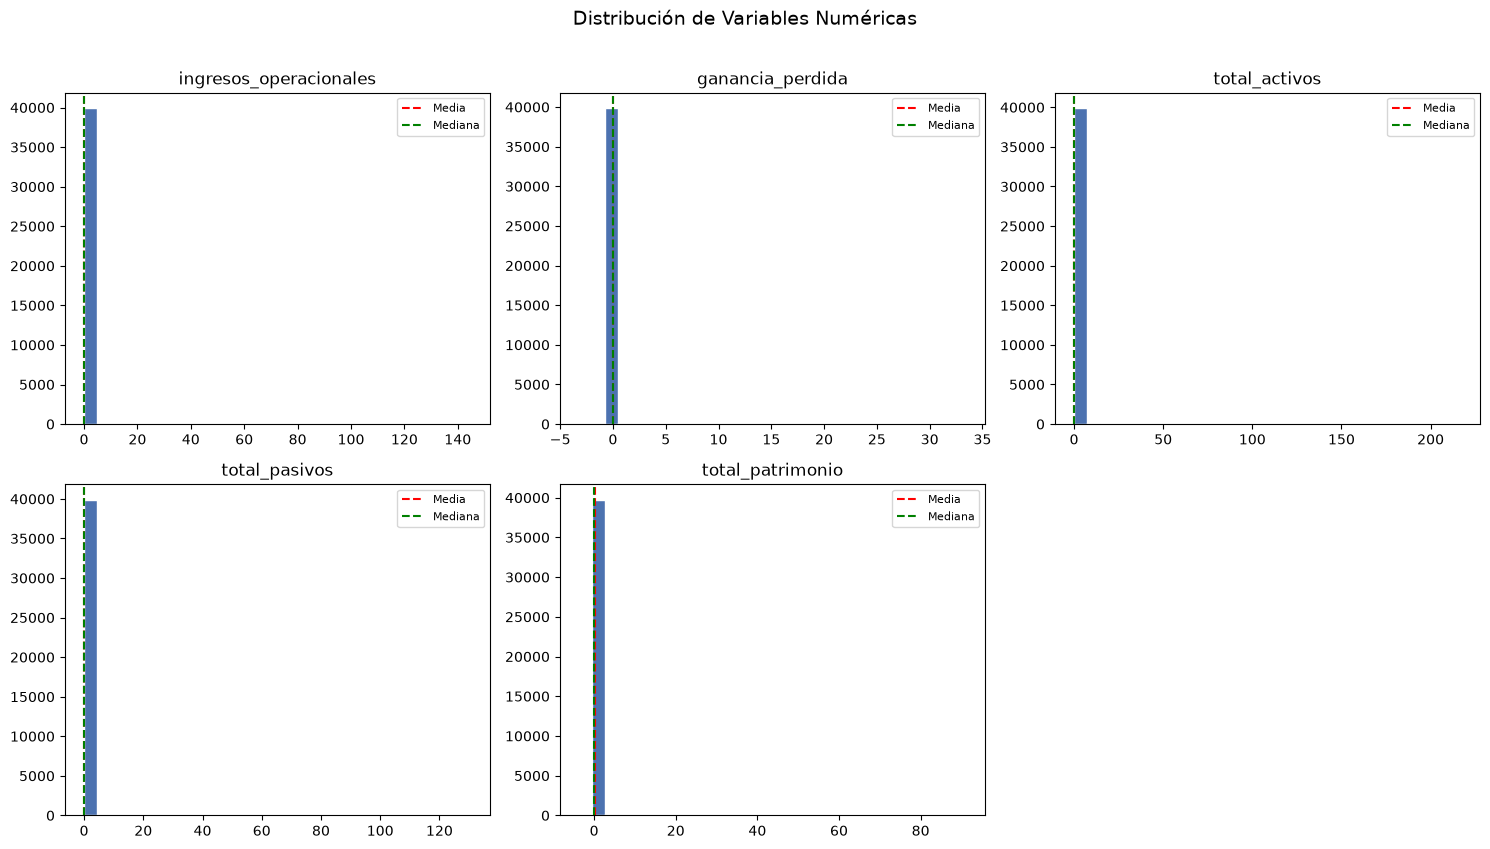

In [149]:
# Distribución de las variables numéricas
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    axes[i].hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col)
    axes[i].axvline(df[col].mean(), color="red", linestyle="--", label="Media")
    axes[i].axvline(df[col].median(), color="green", linestyle="--", label="Mediana")
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribución de Variables Numéricas", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

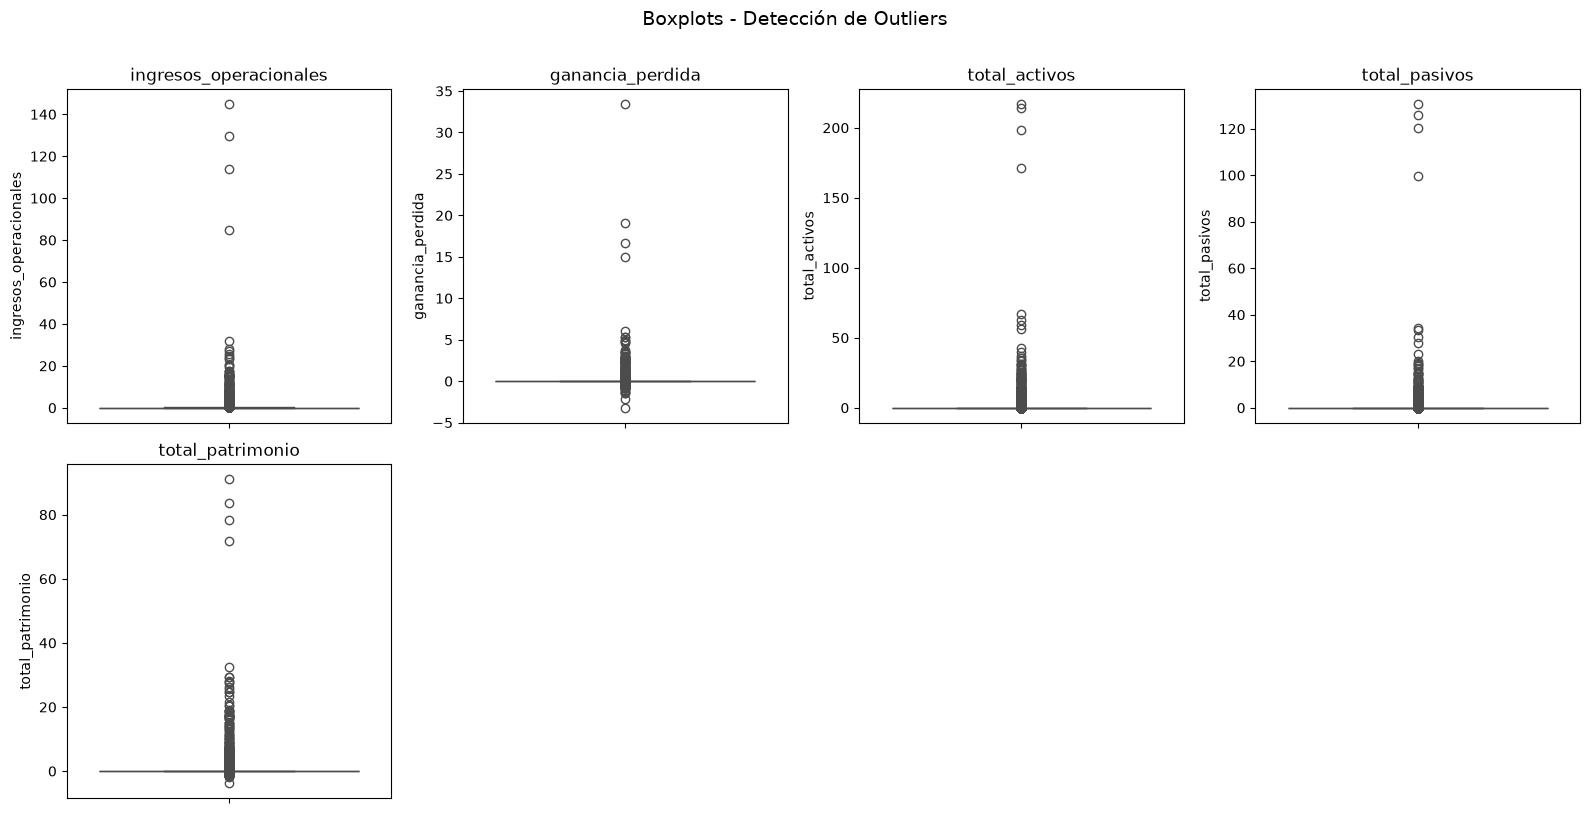

In [150]:
# Boxplots de las variables numéricas para detectar outliers
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(y=df[col], ax=axes[i], color="#4C72B0")
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots - Detección de Outliers", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

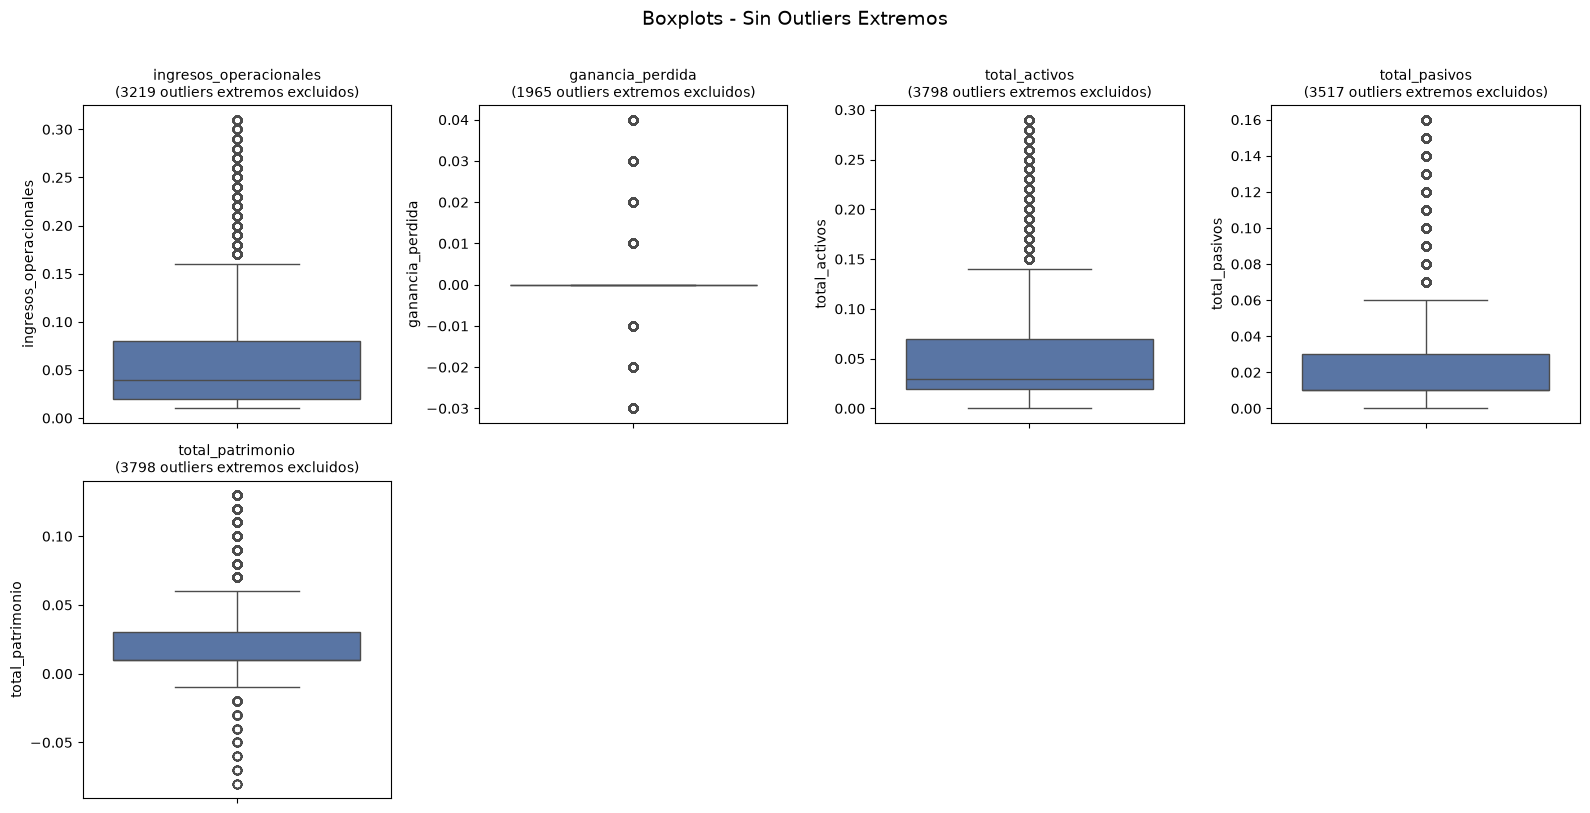

In [151]:
# Boxplots sin outliers extremos (fuera de Q1 - 3*IQR y Q3 + 3*IQR)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    datos = df[col][df[col].between(q1 - 3 * iqr, q3 + 3 * iqr)]
    excluidos = df[col].notna().sum() - len(datos)

    sns.boxplot(y=datos, ax=axes[i], color="#4C72B0")
    axes[i].set_title(f"{col}\n({excluidos} outliers extremos excluidos)", fontsize=10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots - Sin Outliers Extremos", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

<a id="sec-10"></a>
## 10. Limpieza de `ciudad_domicilio`

<a id="sec-10-1"></a>
### 10.1 Detección de variantes

In [152]:
# Ver posibles variantes de ciudad_domicilio agrupando por prefijo

ciudades_unicas = pd.Series(df["ciudad_domicilio"].dropna().unique())

variantes_por_prefijo = (
    ciudades_unicas.groupby(ciudades_unicas.str[:3])
    .agg(list)
    .loc[lambda s: s.str.len() > 1]
)

for prefijo, lista in variantes_por_prefijo.items():
    print(f"Prefijo '{prefijo}': {lista}")

Prefijo 'AGU': ['AGUACHICA', 'AGUAZUL']
Prefijo 'ALB': ['ALBAN', 'ALBANIA']
Prefijo 'ANS': ['ANSERMA', 'ANSERMANUEVO']
Prefijo 'ARA': ['ARAUCA', 'ARATOCA']
Prefijo 'ARM': ['ARMENIA', 'ARMERO']
Prefijo 'BAR': ['BARRANQUILLA', 'BARBOSA', 'BARANOA', 'BARRANCABERMEJA', 'BARRANCAS']
Prefijo 'BEL': ['BELLO', 'BELEN']
Prefijo 'BUC': ['BUCARAMANGA', 'BUCARASICA']
Prefijo 'BUG': ['BUGA', 'BUGALAGRANDE']
Prefijo 'CAL': ['CALI', 'CALOTO', 'CALDAS', 'CALARCA', 'CALIMA']
Prefijo 'CAM': ['CAMPOALEGRE', 'CAMPO DE LA CRUZ', 'CAMPO ALEGRE']
Prefijo 'CAR': ['CARTAGENA', 'CARTAGO', 'CAREPA', 'CARMEN DE VIBORAL']
Prefijo 'CHA': ['CHAPARRAL', 'CHACHAGÜÍ']
Prefijo 'CHI': ['CHIA', 'CHINCHINA', 'CHIQUINQUIRA', 'CHIGORODO', 'CHIRIGUANA']
Prefijo 'CIE': ['CIENAGA DE ORO', 'CIENAGA']
Prefijo 'COR': ['COROZAL', 'CORRALES', 'CORDOBA']
Prefijo 'CUC': ['CUCUTA', 'CUCUNUBA', 'CUCUTILLA']
Prefijo 'DON': ['DONMATIAS', 'DON MATIAS']
Prefijo 'DOS': ['DOSQUEBRADAS', 'DOS QUEBRADAS']
Prefijo 'EL ': ['EL ZULIA', 'EL CARMEN 

<a id="sec-10-2"></a>
### 10.2 Normalización y corrección

In [153]:
# 1. Normalización general (quita tildes y diéresis de forma vectorizada)
df["ciudad_domicilio"] = (
    df["ciudad_domicilio"]
    .astype(str)
    .str.strip()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.upper()
)

# 2. Diccionario de corrección para inconsistencias detectadas
mapeo_ciudades = {
    # Aglutinaciones y separación de palabras
    "DON MATIAS": "DONMATIAS",
    "DOS QUEBRADAS": "DOSQUEBRADAS",
    "CAMPO ALEGRE": "CAMPOALEGRE",
    # Sufijos departamentales y aclaraciones
    "MAICAO GUAJIRA": "MAICAO",
    "MITU VAUPES": "MITU",
    "PUERTO GAITAN (MANACACIAS)": "PUERTO GAITAN",
    "LA PAZ (ROBLES)": "LA PAZ",
    "SAN ANDRES Y PROVIDENCIA": "SAN ANDRES",
    # Nombres oficiales largos vs. comunes
    "GUADALAJARA DE BUGA": "BUGA",
    "VILLA DE SAN DIEGO DE UBATE": "UBATE",
    "VILLA DE SAN DIEGO DE VILLA DE SAN DIEGO DE UBATE": "UBATE",
    "VILLA ROSARIO": "VILLA DEL ROSARIO",
    # Textos corruptos o truncados
    "SAN SEBASTIAN DE BUENAVISMAGDALENA": "SAN SEBASTIAN DE BUENAVISTA",
}

df["ciudad_domicilio"] = df["ciudad_domicilio"].replace(mapeo_ciudades)



<a id="sec-10-3"></a>
### 10.3 Caso especial: Ferretería Central (Boyacá)
Un registro puntual quedó con el nombre del departamento pegado a la ciudad y a la razón social; se corrige a mano.

In [154]:
# 1. Localizar por coincidencia de la razón social
filtro_ferreteria = df["razon_social"].str.contains(
    "FERRETERIA CENTRAL", na=False
) & (df["departamento_domicilio"] == "BOYACA")

# 2. Corregir ciudad y departamento
df.loc[filtro_ferreteria, "ciudad_domicilio"] = "PUERTO BOYACA"
df.loc[filtro_ferreteria, "departamento_domicilio"] = "BOYACA"

# 3. Limpiar la razón social si absorbió el texto del departamento
df.loc[filtro_ferreteria, "razon_social"] = df.loc[
    filtro_ferreteria, "razon_social"
].str.replace(r"BOYACA$", "", regex=True).str.strip()

<a id="sec-11"></a>
## 11. Limpieza de `departamento_domicilio`

<a id="sec-11-1"></a>
### 11.1 Detección de variantes

In [155]:
# Ver posibles variantes de departamento_domicilio agrupando por prefijo
departamentos_unicos = pd.Series(df["departamento_domicilio"].dropna().unique())

variantes_por_prefijo = (
    departamentos_unicos.groupby(departamentos_unicos.str[:3])
    .agg(list)
    .loc[lambda s: s.str.len() >= 1]
)

for prefijo, lista in variantes_por_prefijo.items():
    print(f"Prefijo '{prefijo}': {lista}")

Prefijo 'AMA': ['AMAZONAS']
Prefijo 'ANT': ['ANTIOQUIA']
Prefijo 'ARA': ['ARAUCA']
Prefijo 'ARM': ['ARMENIA']
Prefijo 'ATL': ['ATLANTICO']
Prefijo 'BOG': ['BOGOTA D.C.']
Prefijo 'BOL': ['BOLIVAR']
Prefijo 'BOY': ['BOYACA']
Prefijo 'CAL': ['CALDAS']
Prefijo 'CAQ': ['CAQUETA']
Prefijo 'CAS': ['CASANARE']
Prefijo 'CAU': ['CAUCA']
Prefijo 'CES': ['CESAR']
Prefijo 'CHO': ['CHOCO']
Prefijo 'COR': ['CORDOBA']
Prefijo 'CUN': ['CUNDINAMARCA']
Prefijo 'GUA': ['GUAVIARE', 'GUAINIA', 'GUAJIRA']
Prefijo 'HUI': ['HUILA']
Prefijo 'LA ': ['LA GUAJIRA']
Prefijo 'MAG': ['MAGDALENA']
Prefijo 'MET': ['META']
Prefijo 'MON': ['MONTERIA']
Prefijo 'NAR': ['NARIÑO', 'NARINO']
Prefijo 'NOR': ['NORTE DE SANTANDER']
Prefijo 'PUT': ['PUTUMAYO']
Prefijo 'QUI': ['QUINDIO']
Prefijo 'RIS': ['RISARALDA']
Prefijo 'SAN': ['SANTANDER', 'SAN ANDRES Y PROVIDENCIA']
Prefijo 'SUC': ['SUCRE']
Prefijo 'TOL': ['TOLIMA']
Prefijo 'VAL': ['VALLE', 'VALLE DEL CAUCA', 'VALLEDUPAR']
Prefijo 'VAU': ['VAUPES']
Prefijo 'VIC': ['VICHADA']

<a id="sec-11-2"></a>
### 11.2 Normalización y corrección

In [156]:
# 1. Normalizar a mayúsculas y remover caracteres especiales/eñes
df["departamento_domicilio"] = (
    df["departamento_domicilio"]
    .astype(str)
    .str.strip()
    .str.normalize("NFKD")
    .str.encode("ascii", errors="ignore")
    .str.decode("utf-8")
    .str.upper()
)

# 2. Reubicar ciudades que quedaron registradas en la columna de departamento
# Si ciudad_domicilio quedó vacía o alterada, se asegura el valor correcto
mask_armenia = df["departamento_domicilio"] == "ARMENIA"
df.loc[mask_armenia, "ciudad_domicilio"] = "ARMENIA"
df.loc[mask_armenia, "departamento_domicilio"] = "QUINDIO"

mask_monteria = df["departamento_domicilio"] == "MONTERIA"
df.loc[mask_monteria, "ciudad_domicilio"] = "MONTERIA"
df.loc[mask_monteria, "departamento_domicilio"] = "CORDOBA"

mask_valledupar = df["departamento_domicilio"] == "VALLEDUPAR"
df.loc[mask_valledupar, "ciudad_domicilio"] = "VALLEDUPAR"
df.loc[mask_valledupar, "departamento_domicilio"] = "CESAR"

# 3. Estandarizar nombres de departamentos duplicados
mapeo_deptos = {
    "VALLE": "VALLE DEL CAUCA",
    "GUAJIRA": "LA GUAJIRA",
}

df["departamento_domicilio"] = df["departamento_domicilio"].replace(mapeo_deptos)

<a id="sec-11-3"></a>
### 11.3 Corrección de errores cruzados ciudad-departamento y homologación DIVIPOLA
Se reubican ciudades que habían quedado asociadas a un departamento incorrecto y se homologan nombres de ciudad a su denominación oficial DIVIPOLA.

In [157]:
# FASE 1: Corregir departamentos y errores tipográficos puntuales

# Errores territoriales donde la ciudad es evidente
df.loc[df["ciudad_domicilio"] == "MEDELLIN", "departamento_domicilio"] = (
    "ANTIOQUIA"
)
df.loc[df["ciudad_domicilio"] == "BARRANQUILLA", "departamento_domicilio"] = (
    "ATLANTICO"
)
df.loc[df["ciudad_domicilio"] == "BUCARAMANGA", "departamento_domicilio"] = (
    "SANTANDER"
)
df.loc[df["ciudad_domicilio"] == "PALMIRA", "departamento_domicilio"] = (
    "VALLE DEL CAUCA"
)
df.loc[df["ciudad_domicilio"] == "RIOHACHA", "departamento_domicilio"] = (
    "LA GUAJIRA"
)
df.loc[
    df["ciudad_domicilio"].isin(["CUCUTA", "OCANA", "BUCARASICA"]),
    "departamento_domicilio",
] = "NORTE DE SANTANDER"
df.loc[
    df["ciudad_domicilio"].isin(["FUNZA", "COTA", "MOSQUERA"]),
    "departamento_domicilio",
] = "CUNDINAMARCA"
df.loc[df["ciudad_domicilio"] == "LA TEBAIDA", "departamento_domicilio"] = (
    "QUINDIO"
)

# Caso especial Bogotá (forzar siempre a Bogotá D.C. en ambas columnas)
mask_bogota = df["ciudad_domicilio"].isin(
    ["BOGOTA D.C.", "BOGOTA, D.C.", "BOGOTA"]
)
df.loc[mask_bogota, ["ciudad_domicilio", "departamento_domicilio"]] = (
    "BOGOTA D.C."
)

# Caso especial Anserma en Valle -> Ansermanuevo
df.loc[
    (df["ciudad_domicilio"] == "ANSERMA")
    & (df["departamento_domicilio"] == "VALLE DEL CAUCA"),
    "ciudad_domicilio",
] = "ANSERMANUEVO"

# Typo en Risaralda: Satuario -> Santuario
df.loc[
    (df["ciudad_domicilio"] == "SATUARIO")
    & (df["departamento_domicilio"] == "RISARALDA"),
    "ciudad_domicilio",
] = "SANTUARIO"


# FASE 2: Homologación a nombres oficiales DIVIPOLA

homologacion_nombres = {
    # Ciudades principales y municipios con prefijos/sufijos omitidos
    "CALI": "SANTIAGO DE CALI",
    "CARTAGENA": "CARTAGENA DE INDIAS",
    "CUCUTA": "SAN JOSE DE CUCUTA",
    "BUGA": "GUADALAJARA DE BUGA",
    "UBATE": "VILLA DE SAN DIEGO DE UBATE",
    "CARMEN DE VIBORAL": "EL CARMEN DE VIBORAL",
    "TUMACO": "SAN ANDRES DE TUMACO",
    "SANTAFE DE ANTIOQUIA": "SANTA FE DE ANTIOQUIA",
    "MARIQUITA": "SAN SEBASTIAN DE MARIQUITA",
    "PIENDAMO": "PIENDAMO - TUNIA",
    "SINCE": "SAN LUIS DE SINCE",
    "TOLU": "SANTIAGO DE TOLU",
    "INIRIDA GUAINIA": "INIRIDA",
    "ANTIOQUIA": "SANTA FE DE ANTIOQUIA",
}

# Aplicar reemplazos directos
df["ciudad_domicilio"] = df["ciudad_domicilio"].replace(homologacion_nombres)

# Casos con desambiguación contextual:
# San Pedro en Antioquia -> San Pedro de los Milagros
df.loc[
    (df["ciudad_domicilio"] == "SAN PEDRO")
    & (df["departamento_domicilio"] == "ANTIOQUIA"),
    "ciudad_domicilio",
] = "SAN PEDRO DE LOS MILAGROS"

# Bolívar en Antioquia -> Ciudad Bolívar
df.loc[
    (df["ciudad_domicilio"] == "BOLIVAR")
    & (df["departamento_domicilio"] == "ANTIOQUIA"),
    "ciudad_domicilio",
] = "CIUDAD BOLIVAR"

# Santuario en Antioquia -> El Santuario (en Risaralda el nombre oficial es "Santuario", sin "El";
# por eso esta homologación se condiciona por departamento en vez de aplicarse a toda la columna)
df.loc[
    (df["ciudad_domicilio"] == "SANTUARIO")
    & (df["departamento_domicilio"] == "ANTIOQUIA"),
    "ciudad_domicilio",
] = "EL SANTUARIO"

<a id="sec-11-4"></a>
### 11.4 Verificación de cruces anómalos
Se confirma que ya no existan las combinaciones ciudad-departamento imposibles detectadas inicialmente.

In [158]:
# 1. Comprobar los cruces absurdos específicos citados en el texto
cruces_anomalos_esperados = {
    "BOGOTA D.C.": ["ANTIOQUIA", "CUNDINAMARCA"],
    "MEDELLIN": ["MAGDALENA"],
    "BARRANQUILLA": ["BOLIVAR", "SAN ANDRES Y PROVIDENCIA"],
    "CUCUTA": ["SANTANDER"],
}

condiciones = []
for ciudad, deptos in cruces_anomalos_esperados.items():
    cond = (df["ciudad_domicilio"] == ciudad) & (
        df["departamento_domicilio"].isin(deptos)
    )
    condiciones.append(cond)

filtro_anomalias = pd.concat(condiciones, axis=1).any(axis=1)
df_anomalias_detectadas = df.loc[
    filtro_anomalias,
    ["nit", "razon_social", "ciudad_domicilio", "departamento_domicilio", "ano_de_corte"],
]

print(f"Total de filas con cruces anómalos detectadas: {len(df_anomalias_detectadas)}")
print(df_anomalias_detectadas.to_string(index=False))

# 2. Contar cuántas ciudades únicas aparecen en más de un departamento
ciudades_multidepartamento = (
    df.groupby("ciudad_domicilio")["departamento_domicilio"]
    .nunique()
    .loc[lambda x: x > 1]
)

print(f"\nTotal de nombres de ciudad asociados a >1 departamento: {len(ciudades_multidepartamento)}")
print(ciudades_multidepartamento.head(15))

Total de filas con cruces anómalos detectadas: 0
Empty DataFrame
Columns: [nit, razon_social, ciudad_domicilio, departamento_domicilio, ano_de_corte]
Index: []

Total de nombres de ciudad asociados a >1 departamento: 4
ciudad_domicilio
GRANADA     2
GUAMAL      2
LA UNION    3
RESTREPO    2
Name: departamento_domicilio, dtype: int64


<a id="sec-11-5"></a>
### 11.5 Homónimos legítimos
Se revisan los nombres de ciudad que siguen asociados a más de un departamento, para confirmar que corresponden a municipios distintos y no a errores.

In [159]:
homonimos = ["EL SANTUARIO", "GRANADA", "GUAMAL", "LA UNION", "RESTREPO"]

print(
    df[df["ciudad_domicilio"].isin(homonimos)][
        ["ciudad_domicilio", "departamento_domicilio"]
    ]
    .drop_duplicates()
    .sort_values(by=["ciudad_domicilio", "departamento_domicilio"])
    .to_string(index=False)
)

ciudad_domicilio departamento_domicilio
    EL SANTUARIO              ANTIOQUIA
         GRANADA           CUNDINAMARCA
         GRANADA                   META
          GUAMAL              MAGDALENA
          GUAMAL                   META
        LA UNION              ANTIOQUIA
        LA UNION                 NARINO
        LA UNION        VALLE DEL CAUCA
        RESTREPO                   META
        RESTREPO        VALLE DEL CAUCA


<a id="sec-11-6"></a>
### 11.6 Verificación final
Listado final de departamentos/entidades territoriales tras todas las correcciones de la sección 9.

In [160]:
# Verificar la lista final de departamentos/entidades territoriales
deptos_unicos = sorted(df["departamento_domicilio"].dropna().unique())
print(f"Total entidades territoriales encontradas: {len(deptos_unicos)}")
print(deptos_unicos)

Total entidades territoriales encontradas: 33
['AMAZONAS', 'ANTIOQUIA', 'ARAUCA', 'ATLANTICO', 'BOGOTA D.C.', 'BOLIVAR', 'BOYACA', 'CALDAS', 'CAQUETA', 'CASANARE', 'CAUCA', 'CESAR', 'CHOCO', 'CORDOBA', 'CUNDINAMARCA', 'GUAINIA', 'GUAVIARE', 'HUILA', 'LA GUAJIRA', 'MAGDALENA', 'META', 'NARINO', 'NORTE DE SANTANDER', 'PUTUMAYO', 'QUINDIO', 'RISARALDA', 'SAN ANDRES Y PROVIDENCIA', 'SANTANDER', 'SUCRE', 'TOLIMA', 'VALLE DEL CAUCA', 'VAUPES', 'VICHADA']


<a id="sec-12"></a>
## 12. Consolidación de razón social por NIT
Un mismo NIT puede tener distintos nombres registrados a lo largo de los años; se conserva el más reciente como definitivo.

<a id="sec-12-1"></a>
### 12.1 Detección de inconsistencias

In [161]:
# 1. Agrupar por NIT y contar cuántas razones sociales distintas tiene asociadas
nits_con_varias_razones = (
    df.groupby("nit")["razon_social"]
    .nunique()
    .loc[lambda x: x > 1]
)

print(f"Total de NITs con más de una razón social: {len(nits_con_varias_razones)}")

# 2. Filtrar el DataFrame original para inspeccionar los casos conflictivos
casos_inconsistentes = (
    df[df["nit"].isin(nits_con_varias_razones.index)][
        ["nit", "razon_social", "ano_de_corte"]
    ]
    .drop_duplicates()
    .sort_values(by=["nit", "ano_de_corte"])
)

# Mostrar los primeros casos
print("\nEjemplo de empresas con nombres cambiantes:")
print(casos_inconsistentes.head(20).to_string(index=False))

Total de NITs con más de una razón social: 2230

Ejemplo de empresas con nombres cambiantes:
      nit                                                                                 razon_social  ano_de_corte
800000118 EMPRESA SOCIAL DEL ESTADO HOSPITAL  DEPARTAMENTAL UNIVERSITARIO DEL QUINDIO SAN JUAN DE DIOS          2021
800000118 EMPRESA SOCIAL DEL ESTADO HOSPITAL  DEPARTAMENTAL UNIVERSITARIO DEL QUINDIO SAN JUAN DE DIOS          2022
800000118  EMPRESA SOCIAL DEL ESTADO HOSPITAL DEPARTAMENTAL UNIVERSITARIO DEL QUINDIO SAN JUAN DE DIOS          2023
800002942                                                                                ITELCA S.A.S.          2021
800002942                                                                                ITELCA S.A.S.          2022
800002942                                                                               ITELCA  S.A.S.          2023
800002942                                                                               

<a id="sec-12-2"></a>
### 12.2 Corrección: se conserva el nombre más reciente

In [162]:
# 1. Normalizar espacios en blanco internos y bordes
df["razon_social"] = (
    df["razon_social"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# 2. Obtener el nombre del año más reciente por NIT
nombre_mas_reciente = (
    df.sort_values(by=["nit", "ano_de_corte"], ascending=[True, True])
    .groupby("nit")["razon_social"]
    .last()
)

# 3. Sobreescribir
df["razon_social"] = df["nit"].map(nombre_mas_reciente)

<a id="sec-12-3"></a>
### 12.3 Verificación

In [163]:
# Verificar que ya no existan NIT con más de un nombre asociado
print("NITs con más de un nombre:", (df.groupby("nit")["razon_social"].nunique() > 1).sum())

NITs con más de un nombre: 0


<a id="sec-13"></a>
## 13. Revisión de activos totales en cero

In [164]:
# Contar cuántas empresas quedaron con total_activos en 0.0
activos_cero = (df["total_activos"] == 0).sum()
print(f"Empresas con activos reportados en 0: {activos_cero}")

# Revisar si se trata de empresas en proceso de liquidación o balance vacío
if activos_cero > 0:
    print(
        df[df["total_activos"] == 0][
            ["nit", "razon_social", "ano_de_corte", "ingresos_operacionales"]
        ].head(10)
    )

Empresas con activos reportados en 0: 1137
            nit                                       razon_social  \
1688  900838709                      HUNZAGRO FERTILIZANTES S.A.S.   
1951  900334644                                 NET COMPANY S.A.S.   
2390  901253588                                      INCOMM S.A.S.   
2562  890928110                              SURTIALIMENTOS S.A.S.   
2979  900627999           CAMERON COLOMBIA LLC SUCURSAL COLOMBIANA   
3144  830056174                         SERVIMAX Y COMPAÑIA S.A.S.   
3310  901435143  COMERCIALIZADORA INTERNACIONAL PACIFIC PREMIUM...   
3394  800215548                        DISTRIBUCIONES DISAY S.A.S.   
3481  800022862          FRUTAS DE EXPORTACIO S.A.S. FRUTEX S.A.S.   
3589  900618704                                      ICONYK S.A.S.   

      ano_de_corte  ingresos_operacionales  
1688          2022                    0.15  
1951          2022                    0.12  
2390          2022                    0.10  
2562  

In [165]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   nit                     40000 non-null  str    
 1   razon_social            40000 non-null  str    
 2   supervisor              40000 non-null  str    
 3   region                  40000 non-null  str    
 4   departamento_domicilio  40000 non-null  str    
 5   ciudad_domicilio        40000 non-null  str    
 6   ciiu                    40000 non-null  object 
 7   macrosector             40000 non-null  str    
 8   ingresos_operacionales  40000 non-null  float64
 9   ganancia_perdida        40000 non-null  float64
 10  total_activos           40000 non-null  float64
 11  total_pasivos           40000 non-null  float64
 12  total_patrimonio        40000 non-null  float64
 13  ano_de_corte            40000 non-null  int64  
dtypes: float64(5), int64(1), object(1), str(7)
memory

In [166]:
# Exportar resultados
df_limpio = df.copy()
df_limpio.to_csv('data/proccesed/10.000_Empresas_mas_Grandes_del_País_proccesed.csv', index=False)